# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

from environment.environment import Environment
from experiment import Experiment
from campaigns.slightly_non_stationary_campaign import SlightlyNonStationaryCampaign
from bidders.UCB_based.sliding_window_combinatorial_ucb_like_bidder import SlidingWindowCombinatorialUCBLikeBidder
from bidders.UCB_based.cusum_combinatorial_ucb_like_bidder import CUSUMCombinatorialUCBLikeBidder
from bidders.primal_dual.primal_dual_bidder import PrimalDualBidder

import plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 4: Slightly non-stationary environments with multiple campaigns

### Non-stationary environment

Build a slightly non-stationary environment for the pricing problem. At a high level:
- Rounds are partitioned in intervals
- In each interval the distribution of highest competing bids is fixed
- Each interval has a different distribution

In [6]:
N_TRIALS = 10  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=5, campaign_type=SlightlyNonStationaryCampaign, min_competitors=3, max_competitors=5, conflicts_percentage=0.4, seed=425)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 10000  # number of ads to be shown sequentially = n_rounds = T

RHO = 0.5  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

np.random.seed(123)
MY_VALUATIONS = np.random.uniform(low=0.3, high=0.9, size=environment.N_CAMPAIGNS)  # per-campaign valuations; lower bound > smallest non-zero bid (BIDS_SPACE[1] = 0.1) so every campaign has at least one feasible non-zero bid
print("Per-campaign valuations:", MY_VALUATIONS)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 5
Campaigns:
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1. 1.]
    Number of advertisers: 5
    Number of competitors: 4
    Number of phases: 3
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    Number of phases: 3
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    Number of ph

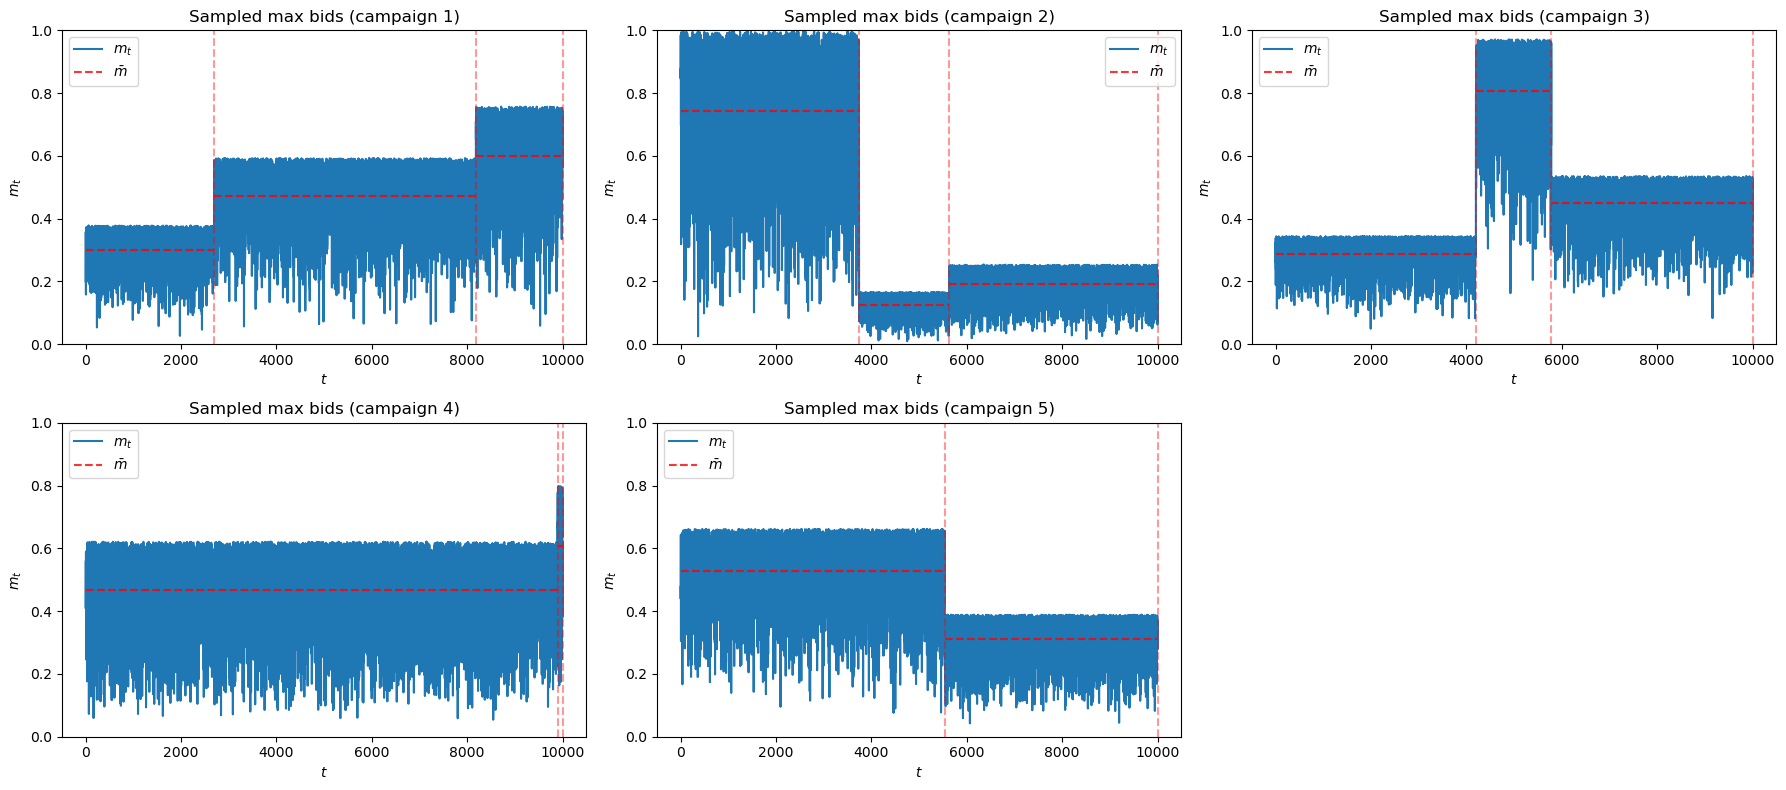

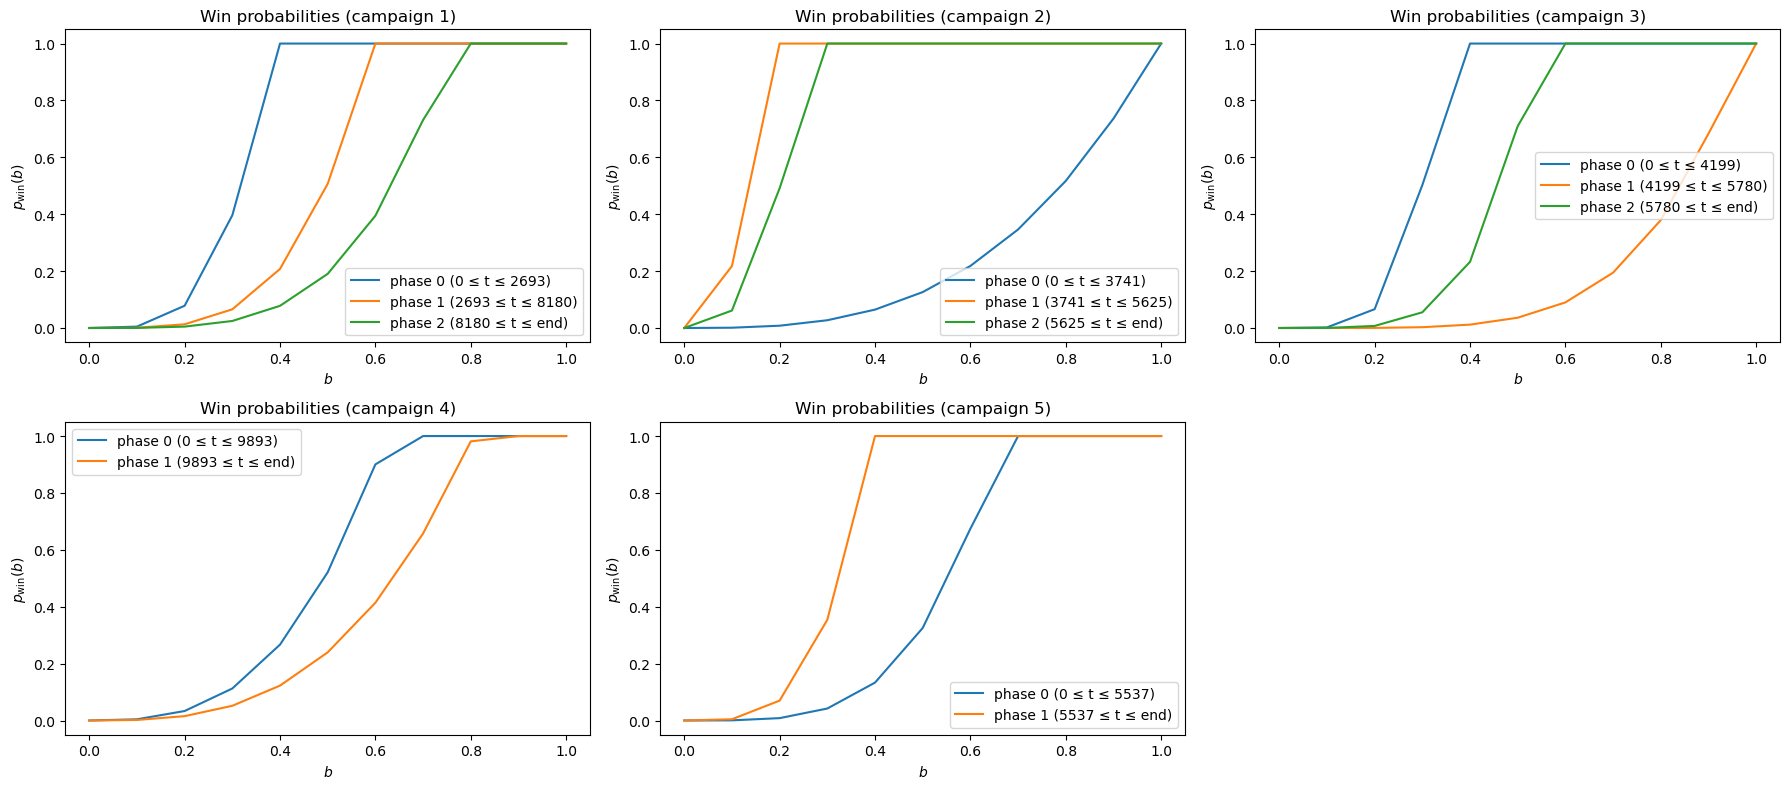

In [7]:
for i, campaign in enumerate(environment.campaigns):
    campaign.generate_random_competing_bids(n_users=N_USERS, seed=17+i)  # generate random competing bids for each advertiser in the campaign

plots.plot_req4_sampled_max_bids_in_time(environment)
plots.plot_win_probabilities(environment, BIDS_SPACE, 'req4_win_probabilities.png')

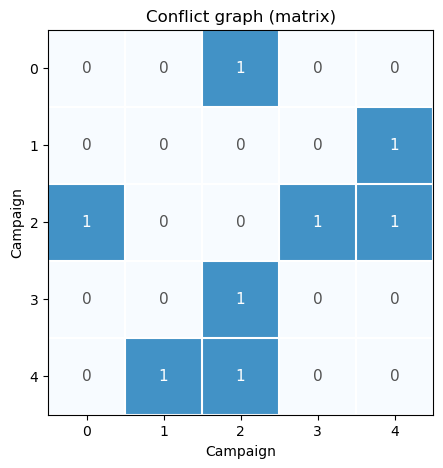

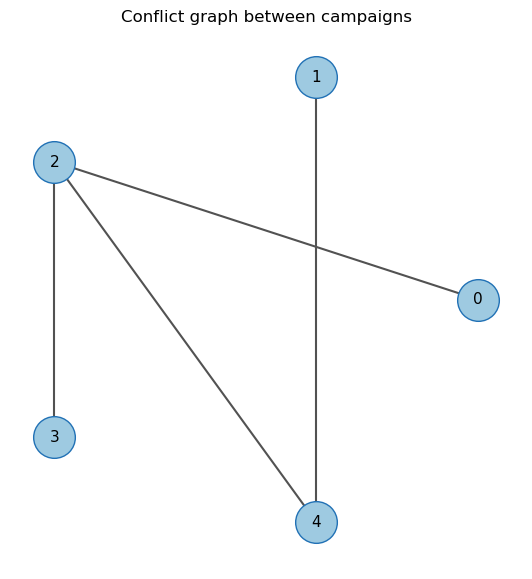

In [8]:
plots.plot_conflict_graph_between_campaigns_matrix_version(environment, 'req4_conflict_matrix.png')
plots.plot_conflict_graph_between_campaigns(environment, 'req4_conflict_graph.png')

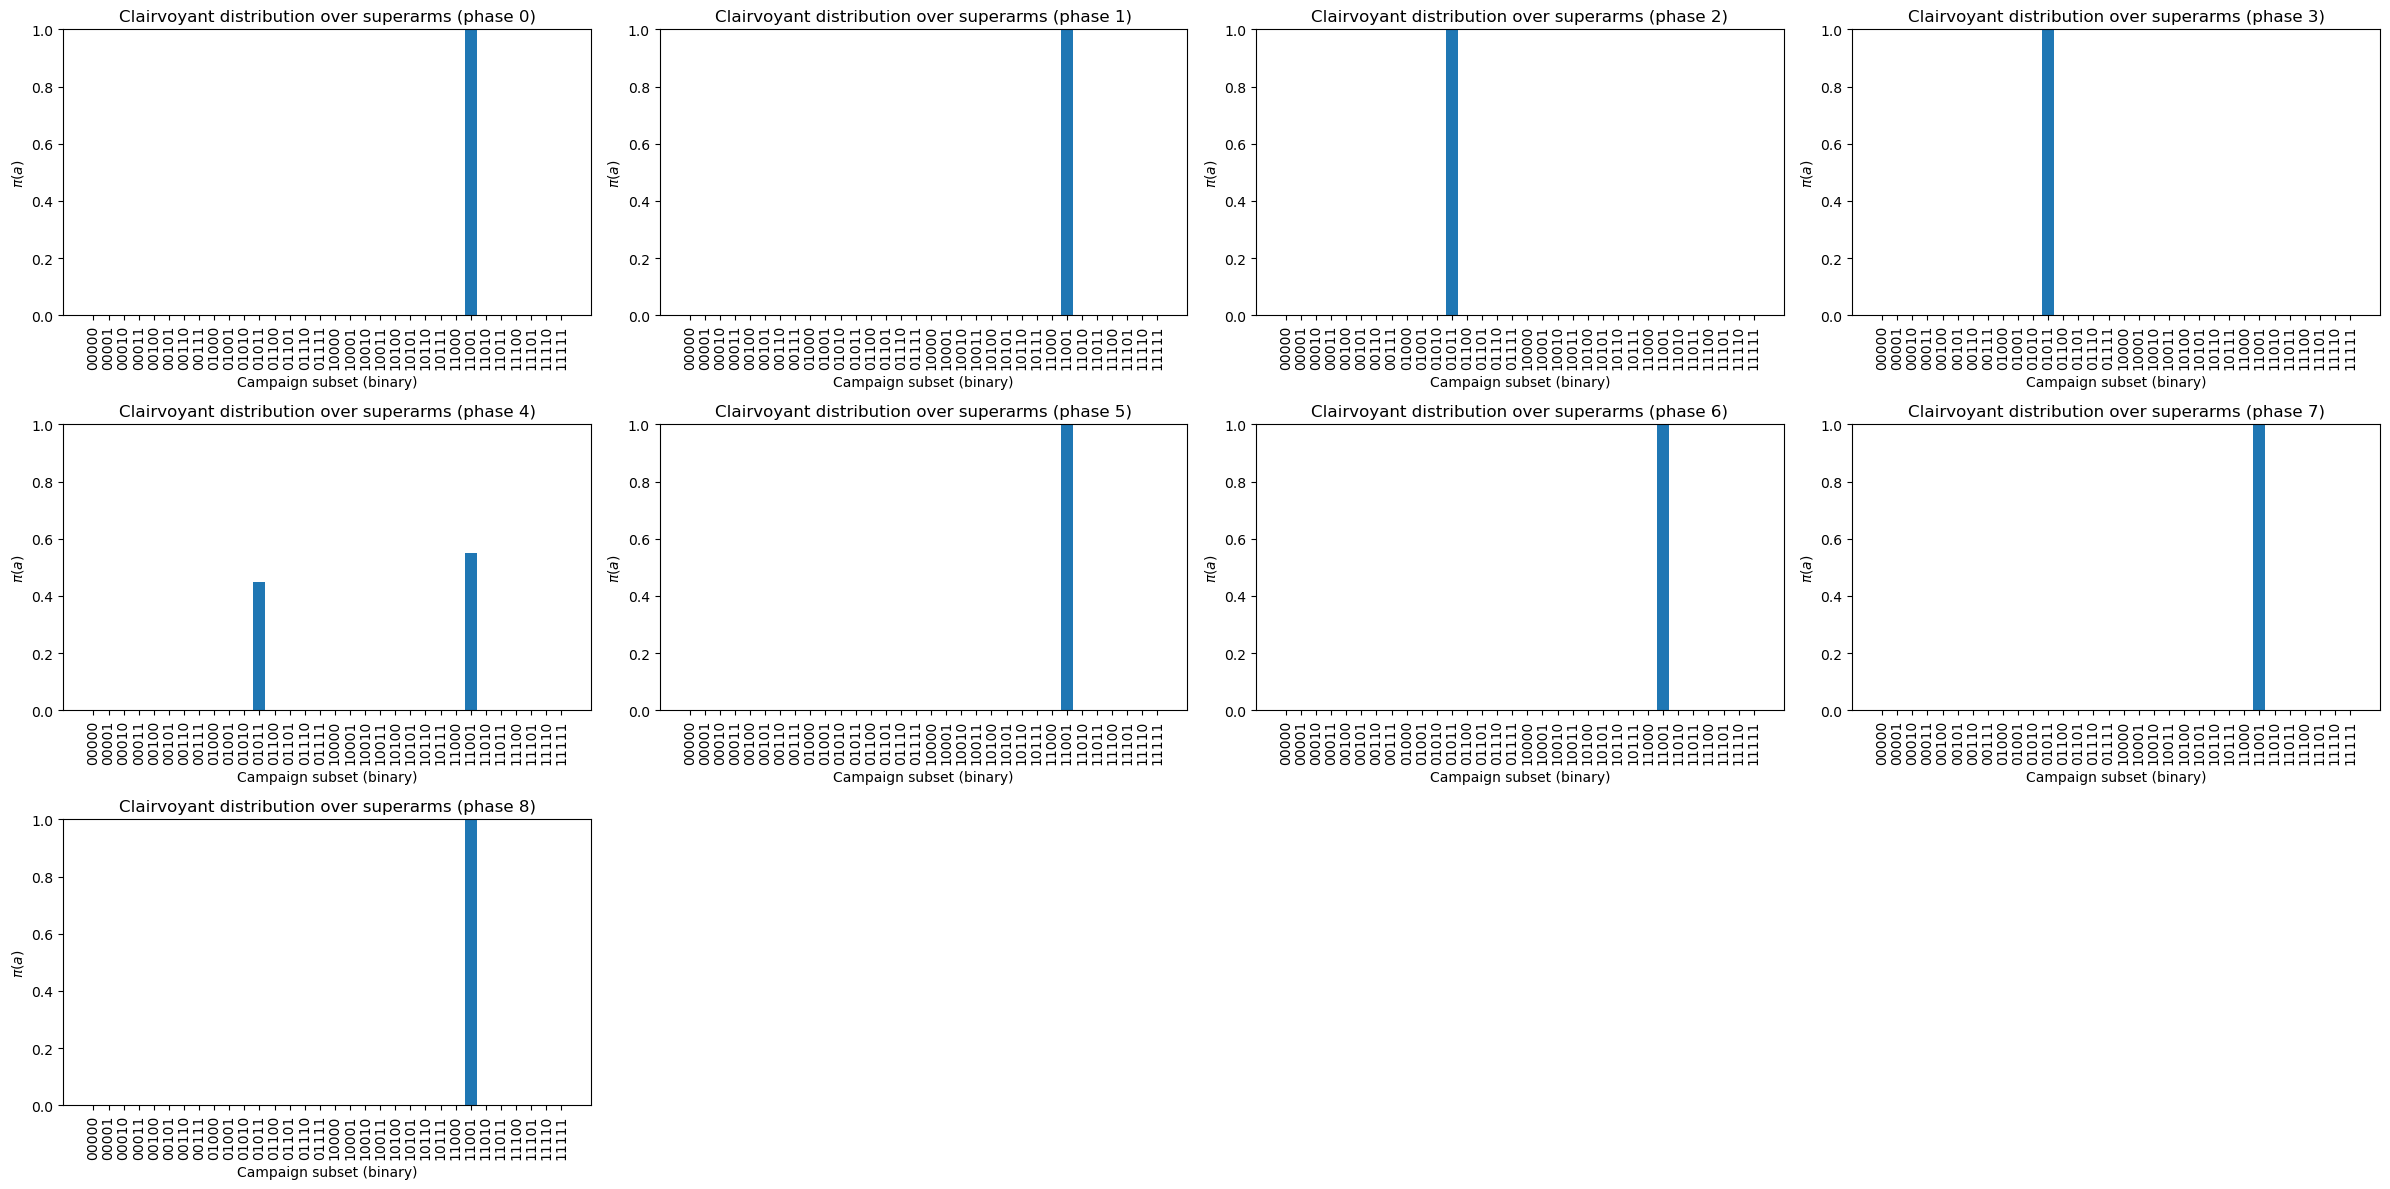

In [9]:
WINDOW_SIZE = 1     # temporary placeholder value

auxiliary_bidder = SlidingWindowCombinatorialUCBLikeBidder(B=STARTING_BUDGET, T=N_USERS, valuations=MY_VALUATIONS.tolist(), environment=environment, window_size=WINDOW_SIZE)

true_clairvoyant_campaign_gammas, true_clairvoyant_superarm_gammas, true_clairvoyant_expected_utilities, true_clairvoyant_expected_payments = environment.compute_true_combinatorial_clairvoyant(auxiliary_bidder, campaign_indices=None)

plots.plot_req4_clairvoyant_distribution_over_campaigns_subsets(superarm_gammas=true_clairvoyant_superarm_gammas)

### Algorithm

Extend the Combinatorial-UCB approach in Requirement 2 with:
- sliding window
- a change detector

### Compare

Compare the performance of:
- Combinatorial-UCB with sliding window
- Combinatorial-UCB with the change detector
- The primal-dual method

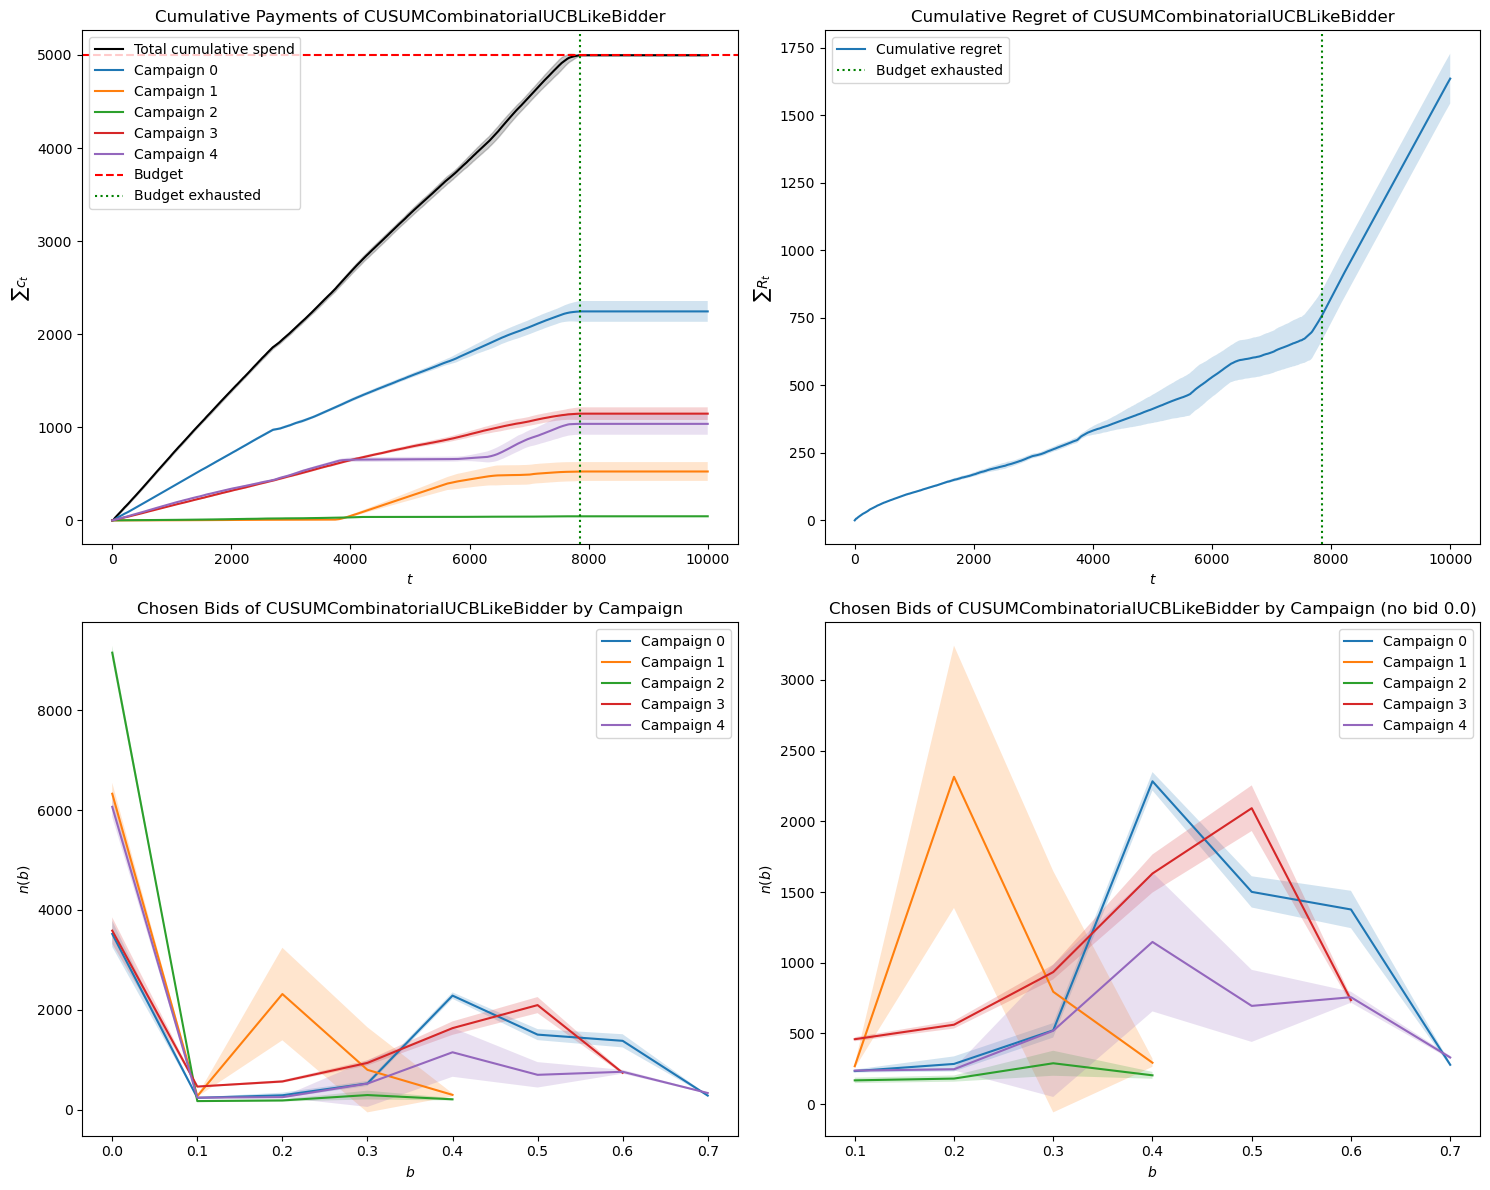

In [10]:
M = 50              # number of samples to be collected in estimation phase of an arm to initialize CUSUM (not too many, or estimation is going to take too long!)
EPS = 0.05          # how much we expect a single reward to deviate from the mean, this acts like a "dampening" factor that prevents estimated std building up from too quickly, limits the rate of "false positives"
                    # this also signals the minimum change in mean that we consider significant in practice, since a change of 0.0000001 would not really be relevant...
H = 3               # cumulate estimated std that signals a change in behavior, this too limits the rate of "false positives" -> larger = fewer "false alarms", but slower detection
ALPHA = 0.05        # exploration probability

budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=CUSUMCombinatorialUCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': MY_VALUATIONS.tolist(), 
                                                              'environment': environment,
                                                              'M': M,
                                                              'eps': EPS,
                                                              'h': H,
                                                              'alpha': ALPHA
                                                            })

budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='true', seed=10)

plots.plot_experiment_result(budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment, "req4_cusum_experiment_results.png")

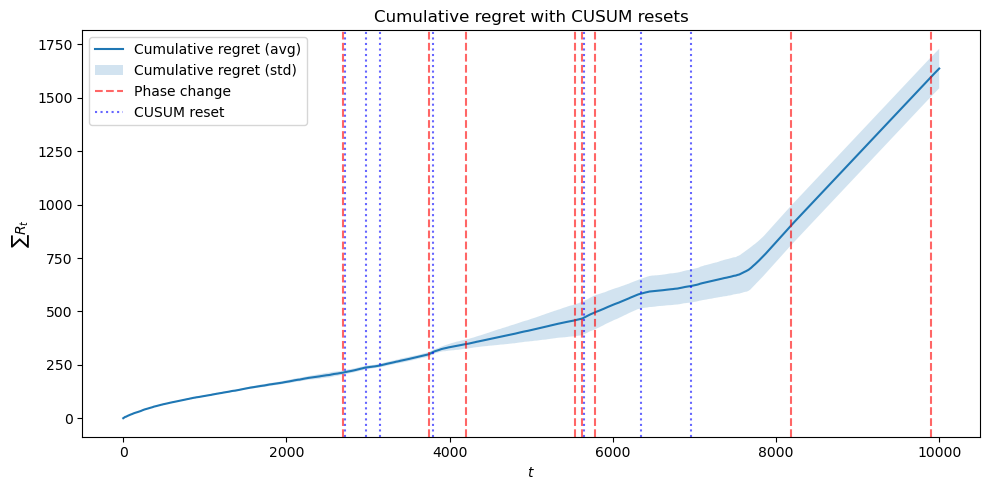

In [11]:
plots.plot_req4_cusum_cumulative_regret_phase_changes(environment, budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment)

c:\Users\richy\Desktop\Polimi\Didattica\A.A. 2025-2026\Online Learning Applications\online-learning-applications-project-2025-2026\bidders\UCB_based\sliding_window_combinatorial_ucb_like_bidder.py:34: RuntimeWarning: Mean of empty slice
  avg_f = np.nanmean(self.f_cache, axis=0)
c:\Users\richy\Desktop\Polimi\Didattica\A.A. 2025-2026\Online Learning Applications\online-learning-applications-project-2025-2026\bidders\UCB_based\sliding_window_combinatorial_ucb_like_bidder.py:35: RuntimeWarning: Mean of empty slice
  avg_c = np.nanmean(self.c_cache, axis=0)


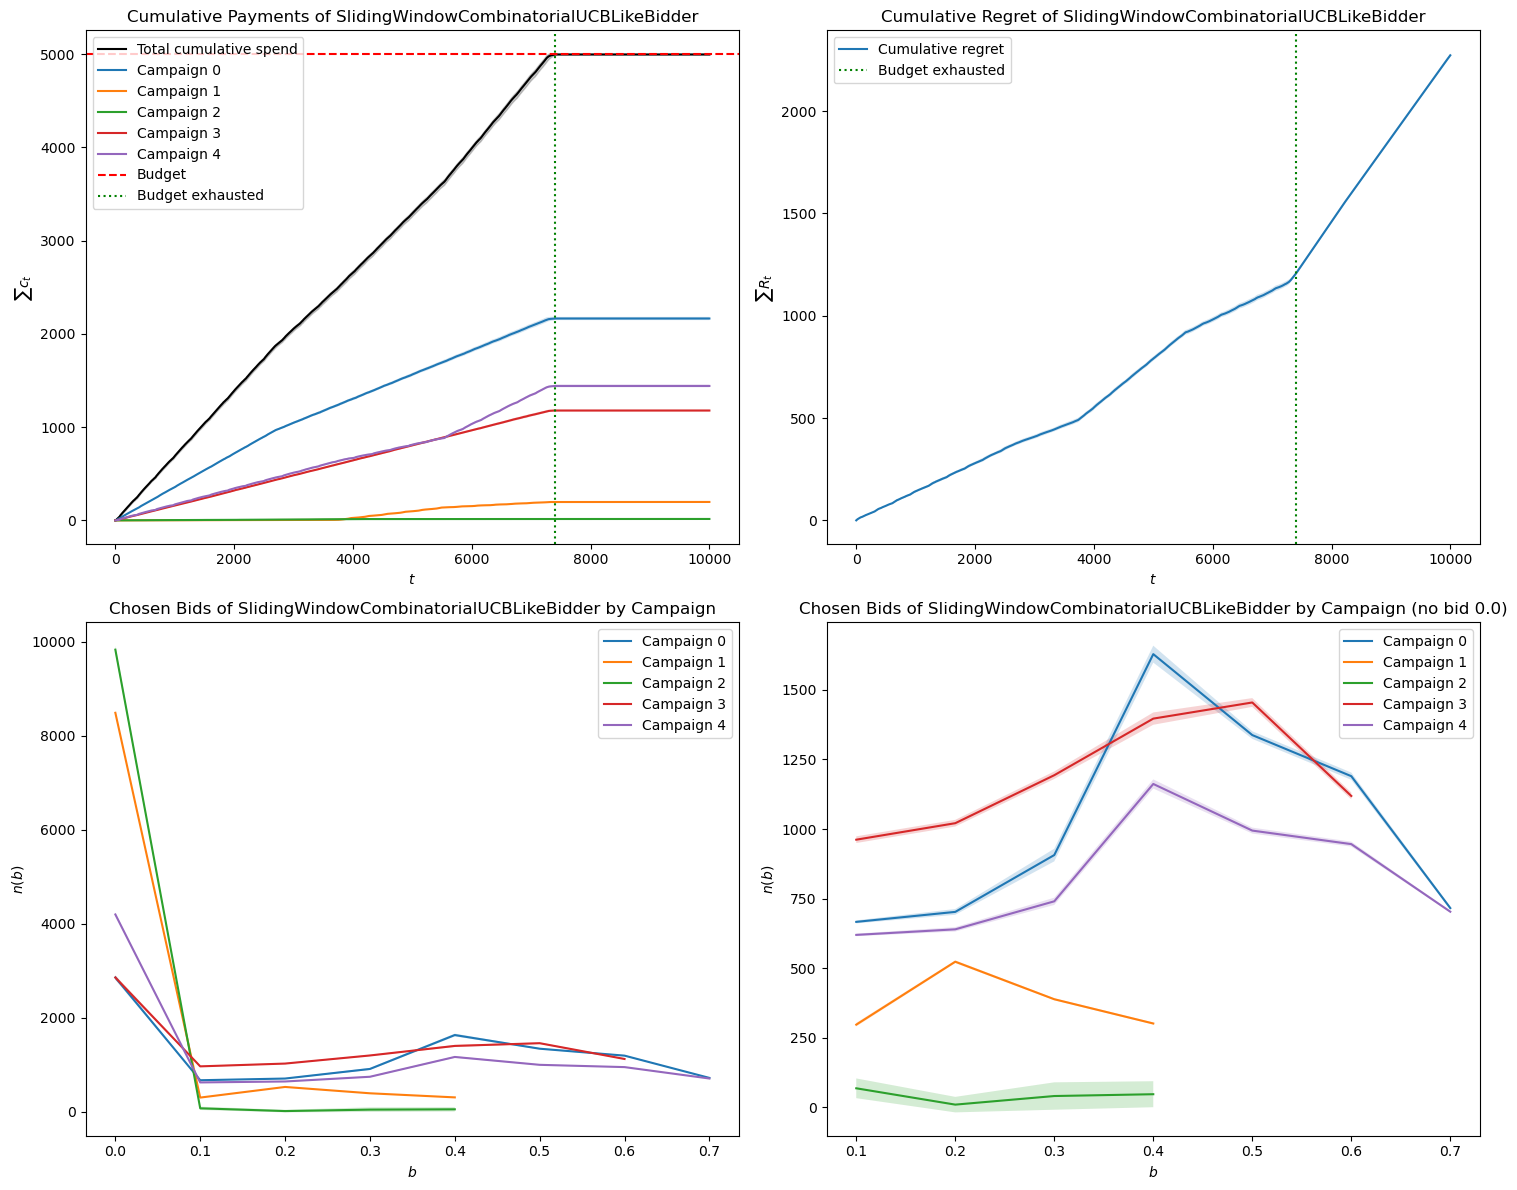

In [12]:
WINDOW_SIZE = int(np.sqrt(N_USERS * np.log(N_USERS)))  # window size for the sliding window UCB-like bidder = sqrt(T log T / T) = sqrt(log T), but we instead use sqrt(T log(T))

budget_constrained_multiple_campaigns_sliding_window_combinatorial_UCB_like_experiment = Experiment(environment=environment,
                                                          bidder_class=SlidingWindowCombinatorialUCBLikeBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': MY_VALUATIONS.tolist(), 
                                                              'environment': environment,
                                                              'window_size': WINDOW_SIZE,
                                                            })

budget_constrained_multiple_campaigns_sliding_window_combinatorial_UCB_like_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='true', seed=10)

plots.plot_experiment_result(budget_constrained_multiple_campaigns_sliding_window_combinatorial_UCB_like_experiment, "req4_sliding_window_experiment_results.png")

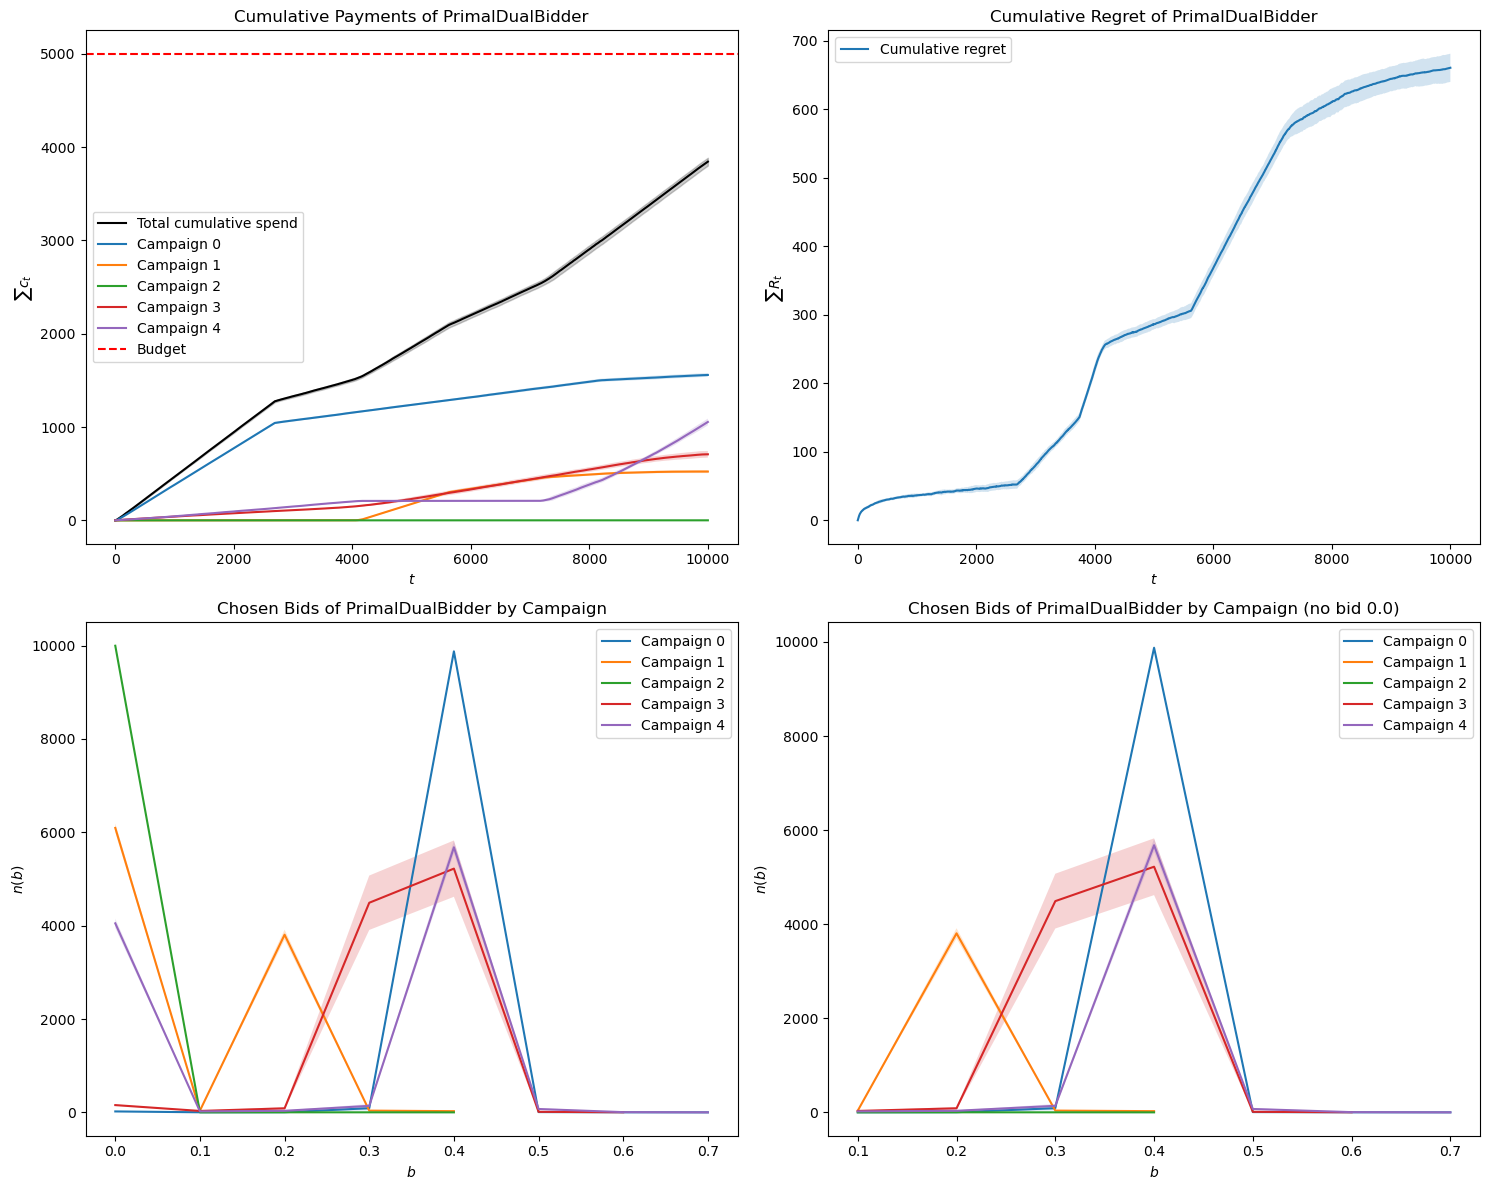

In [13]:
LEARNING_RATE_PRIMAL = 1
LEARNING_RATE_DUAL = 1

budget_constrained_multiple_campaigns_primal_dual_experiment = Experiment(environment=environment,
                                                          bidder_class=PrimalDualBidder, 
                                                          bidder_parameters={
                                                              'B': STARTING_BUDGET, 
                                                              'T': N_USERS, 
                                                              'valuations': MY_VALUATIONS.tolist(), 
                                                              'environment': environment,
                                                              'learning_rate_primal': LEARNING_RATE_PRIMAL,
                                                              'learning_rate_dual': LEARNING_RATE_DUAL
                                                            })

budget_constrained_multiple_campaigns_primal_dual_experiment.run_trials(n_trials=N_TRIALS, clairvoyant_strategy_type='true', seed=10)

plots.plot_experiment_result(budget_constrained_multiple_campaigns_primal_dual_experiment, "req4_primal_dual_experiment_results.png")

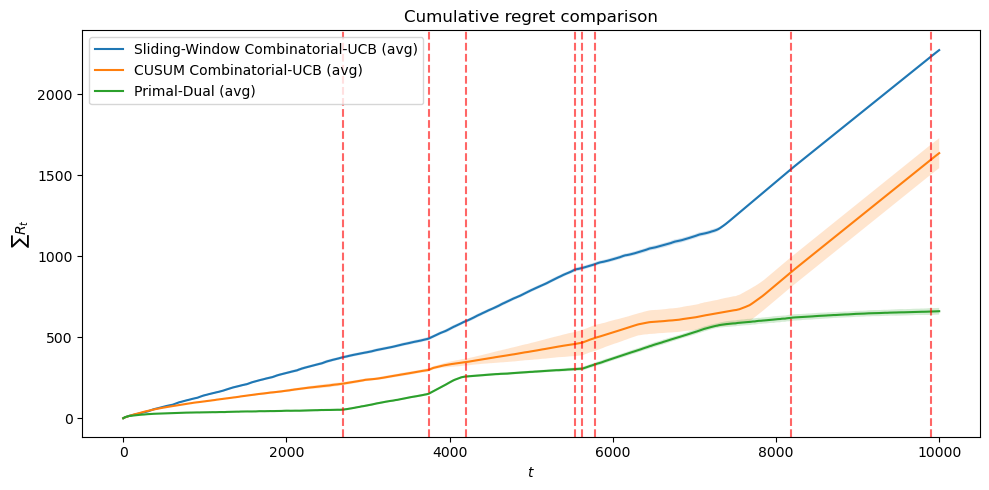

In [14]:
# Combined comparison plots across the three bidders
_bidders_by_name = {
    'Sliding-Window Combinatorial-UCB': budget_constrained_multiple_campaigns_sliding_window_combinatorial_UCB_like_experiment,
    'CUSUM Combinatorial-UCB': budget_constrained_multiple_campaigns_CUSUM_combinatorial_UCB_like_experiment,
    'Primal-Dual': budget_constrained_multiple_campaigns_primal_dual_experiment,
}
plots.plot_req4_cumulative_regrets_combined(environment, _bidders_by_name)

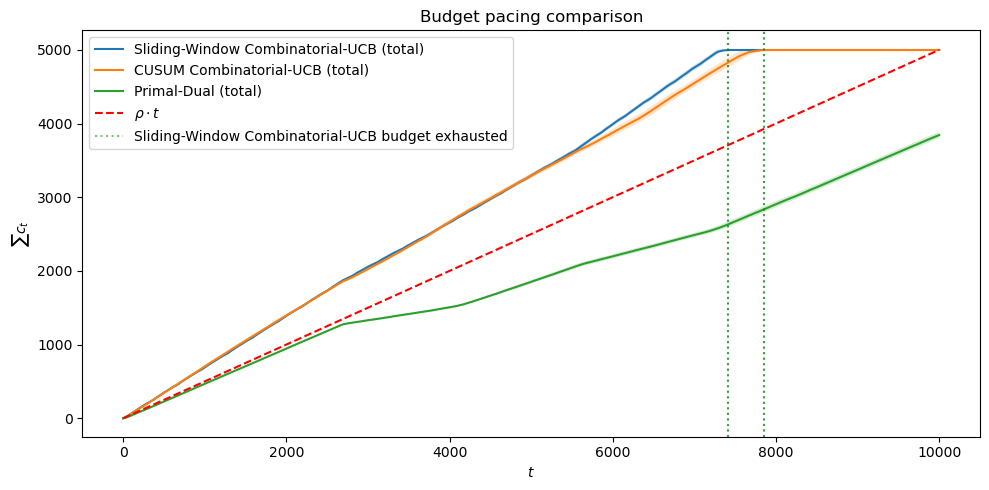

In [15]:
plots.plot_req4_budget_pacing(_bidders_by_name)

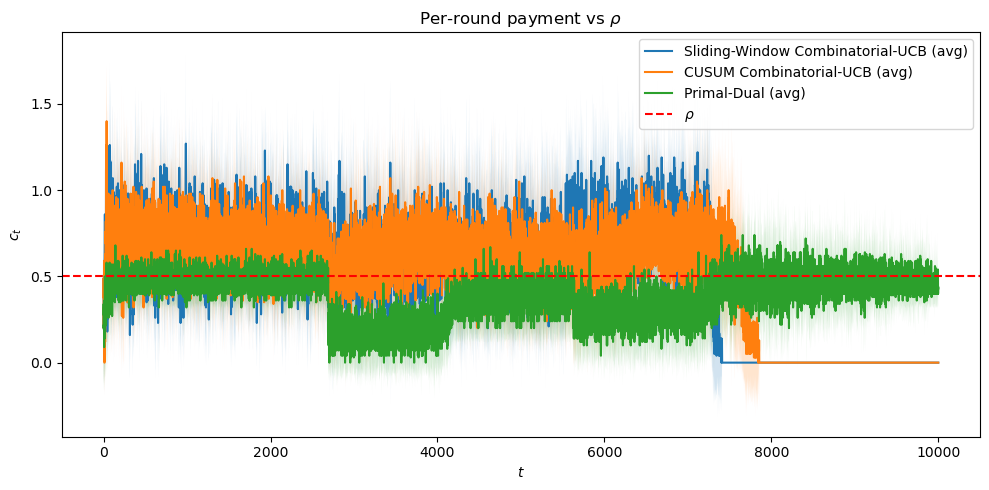

In [16]:
plots.plot_req4_per_round_payment_vs_rho(_bidders_by_name)

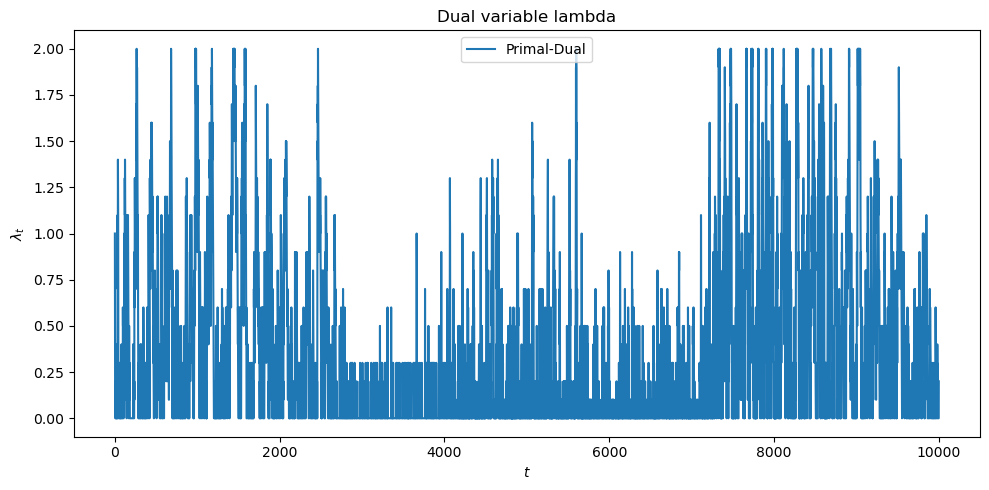

In [17]:
plots.plot_req4_dual_variable_lambda_over_time(_bidders_by_name)